# 출시 후 LLM 리뷰 분석 보고서

## 분석 목적
이미 출시된 게임의 Steam 리뷰와 LLM 분석 결과를 바탕으로,\
개발자가 **현재 유저들이 무엇을 좋아하고 무엇에 불만을 가지는지** 파악하고, **패치·운영 우선순위**를 정하는 것을 목적으로 한다.

## 핵심 질문
1. 현재 이 게임의 출시 후 반응은 긍정적인가, 부정적인가?
2. 유저들은 어떤 요소를 강점으로 보고 있는가?
3. 부정 리뷰에서는 어떤 문제가 반복적으로 나타나는가?
4. 어떤 문제를 먼저 고쳐야 반응 개선 가능성이 높은가?
5. 운영·패치 방향을 어떻게 정리할 수 있는가?

## 사용 데이터
| 파일 | 역할 |
|---|---|
| `llm_review_analysis_result.csv` | 리뷰 1개 단위의 LLM 감성분석 결과 |
| `llm_issue_tags_flat.csv` | 리뷰 안에서 추출된 이슈 태그를 태그 단위로 펼친 결과 |

> 이 보고서는 단순히 감정 분포만 보는 것이 아니라, **좋아한 요소 / 불만 요소 / 긴급도 / 플레이타임 / 출시 후 구간**을 함께 보면서 운영 판단으로 연결한다.

In [1]:
# ============================================================
# 기본 라이브러리
# ============================================================
import os
import ast
import json
import time
import asyncio
import platform
from pathlib import Path
from typing import List, Literal, Optional
from datetime import datetime


# ============================================================
# 데이터 분석용 라이브러리
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ============================================================
# 한글 폰트 설정
# ============================================================
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":  # macOS
    plt.rcParams["font.family"] = "AppleGothic"
else:  # Linux
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 6)

# pandas 출력 옵션
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)


# 1. 설정값

아래 설정값만 바꾸면 다른 게임에도 같은 구조로 보고서를 만들 수 있다.

현재 보고서는 **출시 후 분석**이므로 기본적으로 특정 게임 1개를 대상으로 보는 구조다.  
다만 파일에 여러 게임이 섞여 있으면 `TARGET_APPID` 또는 `TARGET_GAME_NAME`을 지정하면 된다.

둘 다 비워두면 리뷰 수가 가장 많은 게임을 자동 선택한다.


In [2]:
# ============================================================
# 1. 경로 설정
# ============================================================

# 프로젝트 루트 직접 지정
# 다른 환경에서 실행할 경우 ROOT만 본인 프로젝트 경로에 맞게 수정
ROOT = Path(r"C:\Users\joon5\Documents\github\steam-indie-game-analysis")

# LLM 분석 결과 폴더
RUN_NAME = "postlaunch_zoonomaly_v1"
OUTPUT_DIR = ROOT / "data" / "outputs" / RUN_NAME

# LLM 분석 산출물
RESULT_PATH = OUTPUT_DIR / "llm_review_analysis_result.csv"
TAG_PATH = OUTPUT_DIR / "llm_issue_tags_flat.csv"


print("ROOT 존재:", ROOT.exists())
print("LLM 감성분석 결과 존재:", RESULT_PATH.exists())
print("LLM 감성분석 태그 존재:", TAG_PATH.exists())

print("\n프로젝트 루트:", ROOT)
print("LLM 감성분석 결과 :", RESULT_PATH)
print("LLM 감성분석 태그:", TAG_PATH)

# ============================================================
# 1-1. 보고서 설정값
# ============================================================

# 분석 대상 게임
TARGET_APPID = None
TARGET_GAME_NAME = None

# 여러 게임이 들어 있을 때 자동으로 리뷰 수가 가장 많은 게임을 선택할지 여부
AUTO_SELECT_IF_MULTIPLE_GAMES = True

# 보고서에 보여줄 상위 항목 수
TOP_N = 10

# 플레이타임 구간
# 0~1시간: 첫인상/초기 이탈
# 1~5시간: 초반 플레이 경험
# 5~20시간: 중반 플레이 경험
# 20시간 이상: 장기 플레이/누적 불만
PLAYTIME_BINS = [-0.001, 1, 5, 20, np.inf]
PLAYTIME_LABELS = ["0~1시간", "1~5시간", "5~20시간", "20시간 이상"]

# 출시 후 구간 정렬 기준
PERIOD_ORDER = ["D0-D7", "D8-D30", "D0-D30", "D31-D90", "D91-D180", "D181+"]


ROOT 존재: True
LLM 감성분석 결과 존재: True
LLM 감성분석 태그 존재: True

프로젝트 루트: C:\Users\joon5\Documents\github\steam-indie-game-analysis
LLM 감성분석 결과 : C:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\postlaunch_zoonomaly_v1\llm_review_analysis_result.csv
LLM 감성분석 태그: C:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\postlaunch_zoonomaly_v1\llm_issue_tags_flat.csv


# 2. 데이터 불러오기 및 기본 점검

출시 후 분석에서 핵심이 되는 데이터는 두 가지다.

| 데이터 | 분석 관점 |
|---|---|
| 리뷰 단위 데이터 | 리뷰별 감정, 긴급도, 플레이타임, 출시 후 경과일 |
| 태그 단위 데이터 | 반복되는 칭찬 요인과 불만 요인 |


In [3]:
# ============================================================
# 2. 데이터 불러오기
# ============================================================

df_result_raw = pd.read_csv(RESULT_PATH)
df_tags_raw = pd.read_csv(TAG_PATH)

print("df_result_raw shape:", df_result_raw.shape)
print("df_tags_raw shape:", df_tags_raw.shape)

display(df_result_raw.head(3))
display(df_tags_raw.head(3))


df_result_raw shape: (181, 20)
df_tags_raw shape: (378, 15)


,analysis_status,recommendationid,appid,game_name,review_datetime,release_date,days_from_release,release_period,steam_label_text,playtime_at_review_hours,votes_up,weighted_vote_score,llm_sentiment,sentiment_score,primary_issue,issue_tags,urgency,summary,suggested_action,sentiment_relation
0,success,159990344,2101890,Zoonomaly,2024-03-06 19:49:16,2024-03-06,0.0,D0-D30,positive,0.416667,2.0,0.447926,mixed,3.0,optimization,"[{'category': 'optimization', 'sentiment': 'negative', 'evidence': 'optimization is not very good'}, {'category': 't...",medium,게임 자체는 흥미로우나 최적화가 아쉽고 우크라이나어 지원을 요청함.,"최적화 패치를 통해 프레임 드랍 및 성능 문제를 개선하고, 향후 업데이트 시 우크라이나어 현지화 추가를 고려하십시오.",partial_match
1,success,159991191,2101890,Zoonomaly,2024-03-06 20:04:52,2024-03-06,0.0,D0-D30,positive,0.233333,4.0,0.506971,positive,5.0,positive_praise,"[{'category': 'positive_praise', 'sentiment': 'positive', 'evidence': 'creatures are so creepy and weird, best game ...",low,크리처 디자인과 공포 요소에 매우 만족하며 최고의 게임이라고 평가함.,"긍정적인 피드백에 감사하며, 커뮤니티 활성화를 위해 스팀 리뷰 작성 방법 등을 안내하는 공지를 게시하십시오.",exact_match
2,success,159992435,2101890,Zoonomaly,2024-03-06 20:27:11,2024-03-06,0.0,D0-D30,positive,0.283333,1.0,0.497487,mixed,4.0,ui_ux,"[{'category': 'optimization', 'sentiment': 'negative', 'evidence': 'optimizations could be a bit better'}, {'categor...",medium,게임은 좋으나 인트로 텍스트 속도가 너무 빠르고 물리 버그가 존재함.,"인트로 텍스트 가독성을 위해 속도를 늦추거나 일시 정지 기능을 추가하고, 보고된 물리 엔진 버그를 수정하십시오.",partial_match


,recommendationid,appid,game_name,steam_label_text,llm_sentiment,primary_issue,urgency,release_period,playtime_at_review_hours,votes_up,weighted_vote_score,tag_category,issue_name_kor,tag_sentiment,tag_evidence
0,159990344,2101890,Zoonomaly,positive,mixed,optimization,medium,D0-D30,0.416667,2.0,0.447926,optimization,최적화,negative,optimization is not very good
1,159990344,2101890,Zoonomaly,positive,mixed,optimization,medium,D0-D30,0.416667,2.0,0.447926,translation_localization,번역/현지화,neutral,Please add Ukrainian localization
2,159990344,2101890,Zoonomaly,positive,mixed,optimization,medium,D0-D30,0.416667,2.0,0.447926,positive_praise,긍정 칭찬,positive,The game is quite interesting


In [4]:
# ============================================================
# 2-1. 필수 컬럼 확인
# ============================================================

required_result_cols = [
    "recommendationid",
    "appid",
    "game_name",
    "steam_label_text",
    "llm_sentiment",
    "urgency",
    "primary_issue",
    "summary",
    "suggested_action",
]

required_tag_cols = [
    "recommendationid",
    "appid",
    "game_name",
    "tag_category",
    "tag_sentiment",
    "tag_evidence",
]

missing_result_cols = [c for c in required_result_cols if c not in df_result_raw.columns]
missing_tag_cols = [c for c in required_tag_cols if c not in df_tags_raw.columns]

if missing_result_cols:
    raise ValueError(f"df_result에 필요한 컬럼이 없습니다: {missing_result_cols}")

if missing_tag_cols:
    raise ValueError(f"df_tags에 필요한 컬럼이 없습니다: {missing_tag_cols}")

print("필수 컬럼 확인 완료")


필수 컬럼 확인 완료


In [5]:
# ============================================================
# 2-2. 컬럼 표준화 및 파생 컬럼 생성
# ============================================================

df_result = df_result_raw.copy()
df_tags = df_tags_raw.copy()

# ID는 조인 안정성을 위해 문자열로 통일
df_result["recommendationid"] = df_result["recommendationid"].astype(str)
df_tags["recommendationid"] = df_tags["recommendationid"].astype(str)

# 날짜형 변환
for col in ["review_datetime", "release_date"]:
    if col in df_result.columns:
        df_result[col] = pd.to_datetime(df_result[col], errors="coerce")

# 출시 후 경과일 생성
if "days_from_release" not in df_result.columns or df_result["days_from_release"].isna().all():
    if {"review_datetime", "release_date"}.issubset(df_result.columns):
        df_result["days_from_release"] = (df_result["review_datetime"] - df_result["release_date"]).dt.days

# 출시 후 구간 생성
if "release_period" not in df_result.columns:
    df_result["release_period"] = pd.cut(
        df_result["days_from_release"],
        bins=[-1, 7, 30, 90, 180, np.inf],
        labels=["D0-D7", "D8-D30", "D31-D90", "D91-D180", "D181+"]
    ).astype("object")

# 텍스트 라벨 소문자 통일
for col in ["steam_label_text", "llm_sentiment", "urgency", "sentiment_relation"]:
    if col in df_result.columns:
        df_result[col] = df_result[col].astype(str).str.lower().str.strip()

for col in ["steam_label_text", "llm_sentiment", "urgency", "tag_sentiment", "release_period"]:
    if col in df_tags.columns:
        df_tags[col] = df_tags[col].astype(str).str.lower().str.strip()

# release_period는 대문자 형식 유지
if "release_period" in df_result.columns:
    df_result["release_period"] = df_result["release_period"].astype(str).str.upper()
if "release_period" in df_tags.columns:
    df_tags["release_period"] = df_tags["release_period"].astype(str).str.upper()

# 플레이타임 구간 생성
if "playtime_at_review_hours" in df_result.columns:
    df_result["playtime_bin"] = pd.cut(
        df_result["playtime_at_review_hours"],
        bins=PLAYTIME_BINS,
        labels=PLAYTIME_LABELS
    ).astype("object")
else:
    df_result["playtime_bin"] = "정보 없음"

if "playtime_at_review_hours" in df_tags.columns:
    df_tags["playtime_bin"] = pd.cut(
        df_tags["playtime_at_review_hours"],
        bins=PLAYTIME_BINS,
        labels=PLAYTIME_LABELS
    ).astype("object")
else:
    df_tags["playtime_bin"] = "정보 없음"

# 한국어 이슈명 보정
ISSUE_NAME_KOR = {
    "positive_praise": "긍정 칭찬",
    "gameplay_loop": "게임플레이 루프",
    "content_volume": "콘텐츠 분량",
    "control": "조작감",
    "difficulty": "난이도",
    "multiplayer_network": "멀티/네트워크",
    "ui_ux": "UI/UX",
    "bug": "버그",
    "balance": "밸런스",
    "price_value": "가격/가치",
    "crash": "크래시",
    "performance": "성능",
    "other": "기타",
    "graphics_audio": "그래픽/사운드",
    "translation_localization": "번역/현지화",
    "developer_communication": "개발사 소통",
    "progression_grind": "성장/반복 노가다",
    "story": "스토리",
    "optimization": "최적화",
    "monetization": "과금/수익화",
    "save_progression": "저장/진행",
}

if "issue_name_kor" not in df_tags.columns:
    df_tags["issue_name_kor"] = df_tags["tag_category"].map(ISSUE_NAME_KOR).fillna(df_tags["tag_category"])
else:
    df_tags["issue_name_kor"] = df_tags["issue_name_kor"].fillna(df_tags["tag_category"].map(ISSUE_NAME_KOR))

print("전처리 후 데이터 확인")
display(df_result.head(3))
display(df_tags.head(3))


전처리 후 데이터 확인


,analysis_status,recommendationid,appid,game_name,review_datetime,release_date,days_from_release,release_period,steam_label_text,playtime_at_review_hours,votes_up,weighted_vote_score,llm_sentiment,sentiment_score,primary_issue,issue_tags,urgency,summary,suggested_action,sentiment_relation,playtime_bin
0,success,159990344,2101890,Zoonomaly,2024-03-06 19:49:16,2024-03-06,0.0,D0-D30,positive,0.416667,2.0,0.447926,mixed,3.0,optimization,"[{'category': 'optimization', 'sentiment': 'negative', 'evidence': 'optimization is not very good'}, {'category': 't...",medium,게임 자체는 흥미로우나 최적화가 아쉽고 우크라이나어 지원을 요청함.,"최적화 패치를 통해 프레임 드랍 및 성능 문제를 개선하고, 향후 업데이트 시 우크라이나어 현지화 추가를 고려하십시오.",partial_match,0~1시간
1,success,159991191,2101890,Zoonomaly,2024-03-06 20:04:52,2024-03-06,0.0,D0-D30,positive,0.233333,4.0,0.506971,positive,5.0,positive_praise,"[{'category': 'positive_praise', 'sentiment': 'positive', 'evidence': 'creatures are so creepy and weird, best game ...",low,크리처 디자인과 공포 요소에 매우 만족하며 최고의 게임이라고 평가함.,"긍정적인 피드백에 감사하며, 커뮤니티 활성화를 위해 스팀 리뷰 작성 방법 등을 안내하는 공지를 게시하십시오.",exact_match,0~1시간
2,success,159992435,2101890,Zoonomaly,2024-03-06 20:27:11,2024-03-06,0.0,D0-D30,positive,0.283333,1.0,0.497487,mixed,4.0,ui_ux,"[{'category': 'optimization', 'sentiment': 'negative', 'evidence': 'optimizations could be a bit better'}, {'categor...",medium,게임은 좋으나 인트로 텍스트 속도가 너무 빠르고 물리 버그가 존재함.,"인트로 텍스트 가독성을 위해 속도를 늦추거나 일시 정지 기능을 추가하고, 보고된 물리 엔진 버그를 수정하십시오.",partial_match,0~1시간


,recommendationid,appid,game_name,steam_label_text,llm_sentiment,primary_issue,urgency,release_period,playtime_at_review_hours,votes_up,weighted_vote_score,tag_category,issue_name_kor,tag_sentiment,tag_evidence,playtime_bin
0,159990344,2101890,Zoonomaly,positive,mixed,optimization,medium,D0-D30,0.416667,2.0,0.447926,optimization,최적화,negative,optimization is not very good,0~1시간
1,159990344,2101890,Zoonomaly,positive,mixed,optimization,medium,D0-D30,0.416667,2.0,0.447926,translation_localization,번역/현지화,neutral,Please add Ukrainian localization,0~1시간
2,159990344,2101890,Zoonomaly,positive,mixed,optimization,medium,D0-D30,0.416667,2.0,0.447926,positive_praise,긍정 칭찬,positive,The game is quite interesting,0~1시간


# 3. 분석 대상 게임 선택

출시 후 분석은 특정 게임의 운영 판단을 돕는 것이 목적이다.  
따라서 여러 게임이 섞여 있다면 한 게임을 선택해서 분석한다.


In [6]:
# ============================================================
# 3. 분석 대상 게임 선택
# ============================================================

game_counts = (
    df_result
    .groupby(["appid", "game_name"], dropna=False)
    .size()
    .reset_index(name="review_count")
    .sort_values("review_count", ascending=False)
)

print("현재 데이터에 포함된 게임 목록")
display(game_counts)

if TARGET_APPID is not None:
    df_game = df_result[df_result["appid"] == TARGET_APPID].copy()
    selected_reason = f"TARGET_APPID={TARGET_APPID} 기준 선택"
elif TARGET_GAME_NAME is not None:
    df_game = df_result[df_result["game_name"] == TARGET_GAME_NAME].copy()
    selected_reason = f"TARGET_GAME_NAME={TARGET_GAME_NAME} 기준 선택"
else:
    if df_result["appid"].nunique() == 1:
        df_game = df_result.copy()
        selected_reason = "데이터에 게임이 1개만 있어 자동 선택"
    elif AUTO_SELECT_IF_MULTIPLE_GAMES:
        selected_appid = game_counts.iloc[0]["appid"]
        selected_name = game_counts.iloc[0]["game_name"]
        df_game = df_result[df_result["appid"] == selected_appid].copy()
        selected_reason = f"여러 게임 중 리뷰 수가 가장 많은 게임 자동 선택: {selected_name}"
    else:
        raise ValueError("여러 게임이 있습니다. TARGET_APPID 또는 TARGET_GAME_NAME을 지정해 주세요.")

if df_game.empty:
    raise ValueError("선택된 게임 데이터가 없습니다. TARGET_APPID 또는 TARGET_GAME_NAME을 확인해 주세요.")

selected_appid = df_game["appid"].iloc[0]
selected_game_name = df_game["game_name"].iloc[0]

df_game_tags = df_tags[df_tags["appid"] == selected_appid].copy()

selected_game_info = pd.DataFrame({
    "항목": ["게임명", "appid", "선택 기준", "분석 리뷰 수", "분석 태그 수"],
    "값": [selected_game_name, selected_appid, selected_reason, f"{len(df_game):,}개", f"{len(df_game_tags):,}개"]
})

display(selected_game_info)


현재 데이터에 포함된 게임 목록


,appid,game_name,review_count
0,2101890,Zoonomaly,181


,항목,값
0,게임명,Zoonomaly
1,appid,2101890
2,선택 기준,데이터에 게임이 1개만 있어 자동 선택
3,분석 리뷰 수,181개
4,분석 태그 수,378개


# 4. 출시 후 반응 기본 요약

이 단계에서는 현재 게임의 전체 반응 상태를 빠르게 확인한다.

핵심 지표는 다음과 같다.

| 지표 | 의미 |
|---|---|
| Steam 긍정률 | 유저가 최종적으로 추천했는지 여부 |
| LLM 긍정률 | 리뷰 본문에서 실제 긍정 표현이 얼마나 강한지 |
| LLM 부정+혼합 비율 | 추천 여부와 별개로 불만이나 아쉬움이 포함된 비율 |
| High urgency 비율 | 빠르게 대응해야 할 가능성이 높은 리뷰 비율 |
| 플레이타임 | 불만이 초반 이탈인지, 장기 플레이 후 누적 불만인지 판단 |


In [7]:
# ============================================================
# 4. 출시 후 반응 기본 요약
# ============================================================

def safe_rate(series, condition):
    if len(series) == 0:
        return np.nan
    return condition(series).mean()

def pct(value):
    if pd.isna(value):
        return "-"
    return f"{value * 100:.1f}%"

def num(value, digits=1):
    if pd.isna(value):
        return "-"
    return f"{value:.{digits}f}"

total_reviews = len(df_game)
steam_positive_rate = safe_rate(df_game["steam_label_text"], lambda s: s.eq("positive"))
llm_positive_rate = safe_rate(df_game["llm_sentiment"], lambda s: s.eq("positive"))
llm_negative_mixed_rate = safe_rate(df_game["llm_sentiment"], lambda s: s.isin(["negative", "mixed"]))
high_urgency_rate = safe_rate(df_game["urgency"], lambda s: s.eq("high"))

release_date = df_game["release_date"].dropna().min() if "release_date" in df_game.columns else pd.NaT
first_review_date = df_game["review_datetime"].dropna().min() if "review_datetime" in df_game.columns else pd.NaT
last_review_date = df_game["review_datetime"].dropna().max() if "review_datetime" in df_game.columns else pd.NaT

overview_table = pd.DataFrame({
    "항목": [
        "게임명",
        "appid",
        "출시일",
        "분석 리뷰 수",
        "분석 태그 수",
        "분석 표본 내 Steam 라벨 긍정률",
        "LLM 긍정률",
        "LLM 부정+혼합 비율",
        "High urgency 비율",
        "분석 리뷰 시작일",
        "분석 리뷰 종료일",
        "평균 플레이타임(리뷰 시점)",
        "중앙값 플레이타임(리뷰 시점)"
    ],
    "값": [
        selected_game_name,
        selected_appid,
        release_date.date() if pd.notna(release_date) else "-",
        f"{total_reviews:,}개",
        f"{len(df_game_tags):,}개",
        pct(steam_positive_rate),
        pct(llm_positive_rate),
        pct(llm_negative_mixed_rate),
        pct(high_urgency_rate),
        first_review_date.date() if pd.notna(first_review_date) else "-",
        last_review_date.date() if pd.notna(last_review_date) else "-",
        f"{num(df_game['playtime_at_review_hours'].mean())}시간" if "playtime_at_review_hours" in df_game.columns else "-",
        f"{num(df_game['playtime_at_review_hours'].median())}시간" if "playtime_at_review_hours" in df_game.columns else "-",
    ]
})

display(overview_table)


,항목,값
0,게임명,Zoonomaly
1,appid,2101890
2,출시일,2024-03-06
3,분석 리뷰 수,181개
4,분석 태그 수,378개
5,분석 표본 내 Steam 라벨 긍정률,64.6%
6,LLM 긍정률,47.5%
7,LLM 부정+혼합 비율,51.4%
8,High urgency 비율,32.0%
9,분석 리뷰 시작일,2024-03-06


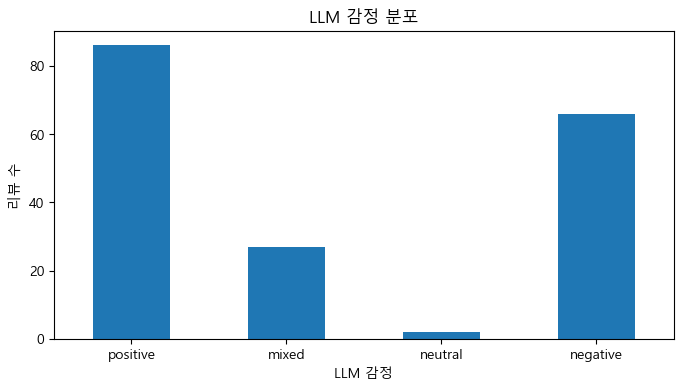

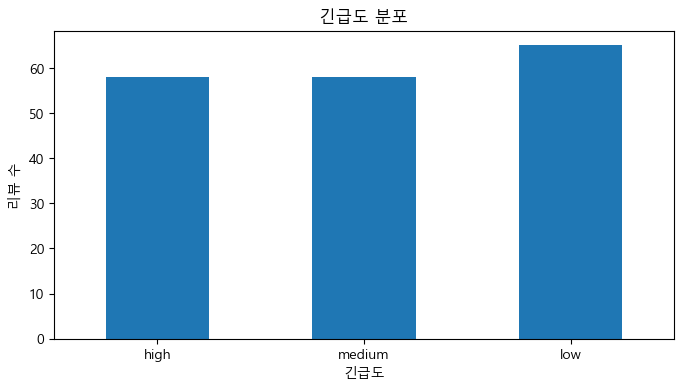

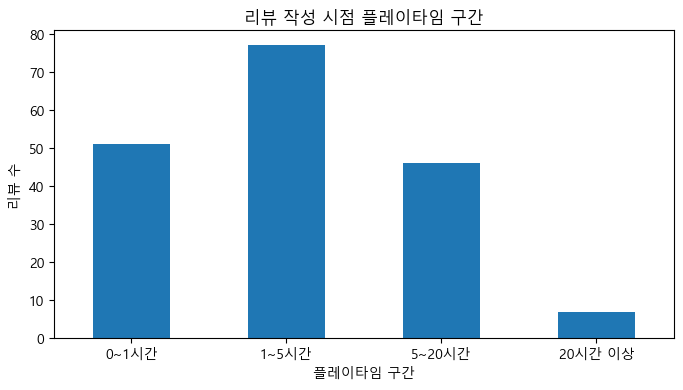

In [ ]:
# ============================================================
# 4-1. 기본 분포 시각화
# ============================================================

if "llm_sentiment" in df_game.columns:
    sentiment_order = ["positive", "mixed", "neutral", "negative"]
    sentiment_counts = df_game["llm_sentiment"].value_counts().reindex(sentiment_order).dropna()

    ax = sentiment_counts.plot(kind="bar", figsize=(8, 4))
    ax.set_title("LLM 감정 분포")
    ax.set_xlabel("LLM 감정")
    ax.set_ylabel("리뷰 수")
    plt.xticks(rotation=0)
    plt.show()

if "playtime_bin" in df_game.columns:
    playtime_counts = df_game["playtime_bin"].value_counts().reindex(PLAYTIME_LABELS).dropna()

    ax = playtime_counts.plot(kind="bar", figsize=(8, 4))
    ax.set_title("리뷰 작성 시점 플레이타임 구간")
    ax.set_xlabel("플레이타임 구간")
    ax.set_ylabel("리뷰 수")
    plt.xticks(rotation=0)
    plt.show()


# 5. 출시 후 구간별 반응 변화

출시 후 분석에서는 단순 전체 평균보다 **시간에 따른 반응 변화**가 중요하다.

예를 들어 출시 초반에는 조작, 튜토리얼, 최적화 문제가 많이 나오고, 시간이 지난 뒤에는 콘텐츠 분량, 반복성, 밸런스 문제가 더 크게 나타날 수 있다.


,release_period,review_count,steam_positive_rate,llm_positive_rate,llm_negative_mixed_rate,high_urgency_rate,avg_playtime_hours,median_playtime_hours
0,D0-D30,91,0.604396,0.428571,0.560440,0.351648,3.223626,1.500000
2,D31-D90,27,0.703704,0.555556,0.407407,0.333333,7.119753,4.383333
3,D91-D180,18,0.722222,0.444444,0.555556,0.222222,4.213889,4.608333
1,D181+,45,0.666667,0.533333,0.466667,0.288889,6.917778,3.883333


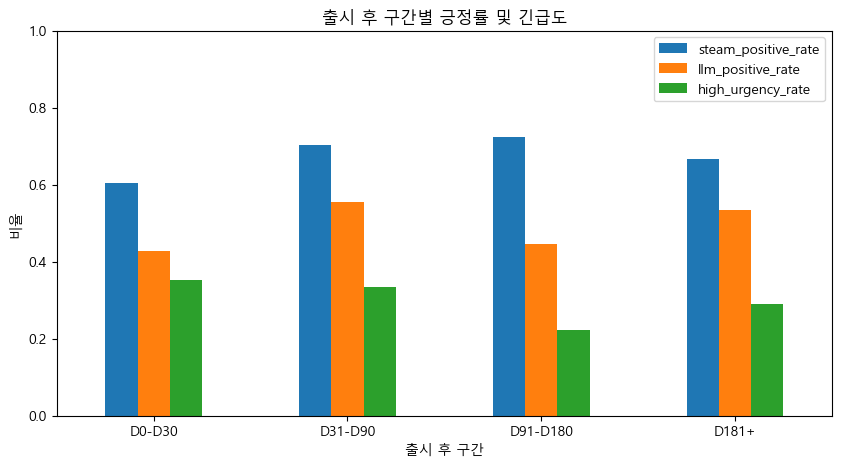

In [9]:
# ============================================================
# 5. 출시 후 구간별 반응 변화
# ============================================================

def sort_period_table(df, period_col="release_period"):
    result = df.copy()
    result["_period_order"] = result[period_col].apply(lambda x: PERIOD_ORDER.index(x) if x in PERIOD_ORDER else 999)
    result = result.sort_values(["_period_order", period_col]).drop(columns="_period_order")
    return result

period_summary = (
    df_game
    .groupby("release_period", dropna=False)
    .agg(
        review_count=("recommendationid", "count"),
        steam_positive_rate=("steam_label_text", lambda s: s.eq("positive").mean()),
        llm_positive_rate=("llm_sentiment", lambda s: s.eq("positive").mean()),
        llm_negative_mixed_rate=("llm_sentiment", lambda s: s.isin(["negative", "mixed"]).mean()),
        high_urgency_rate=("urgency", lambda s: s.eq("high").mean()),
        avg_playtime_hours=("playtime_at_review_hours", "mean"),
        median_playtime_hours=("playtime_at_review_hours", "median"),
    )
    .reset_index()
)

period_summary = sort_period_table(period_summary)

display(period_summary)

if not period_summary.empty:
    plot_df = period_summary.set_index("release_period")[["steam_positive_rate", "llm_positive_rate", "high_urgency_rate"]]

    ax = plot_df.plot(kind="bar", figsize=(10, 5))
    ax.set_title("출시 후 구간별 긍정률 및 긴급도")
    ax.set_xlabel("출시 후 구간")
    ax.set_ylabel("비율")
    plt.xticks(rotation=0)
    plt.ylim(0, 1)
    plt.show()


,days_from_release,review_count,steam_positive_rate,high_urgency_rate
0,0,12,0.916667,0.166667
1,1,20,0.550000,0.400000
2,2,15,0.400000,0.400000
3,3,7,0.571429,0.428571
4,4,2,0.500000,0.500000
5,5,5,0.600000,0.400000
6,6,3,0.333333,0.333333
7,7,1,1.000000,0.000000
8,8,2,1.000000,0.000000
9,10,2,1.000000,0.000000


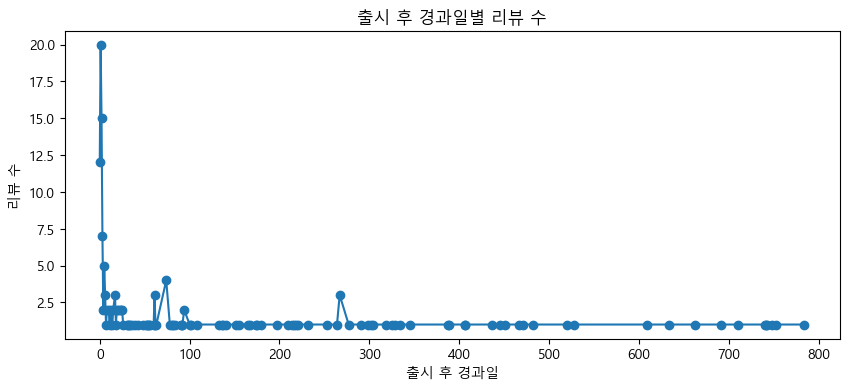

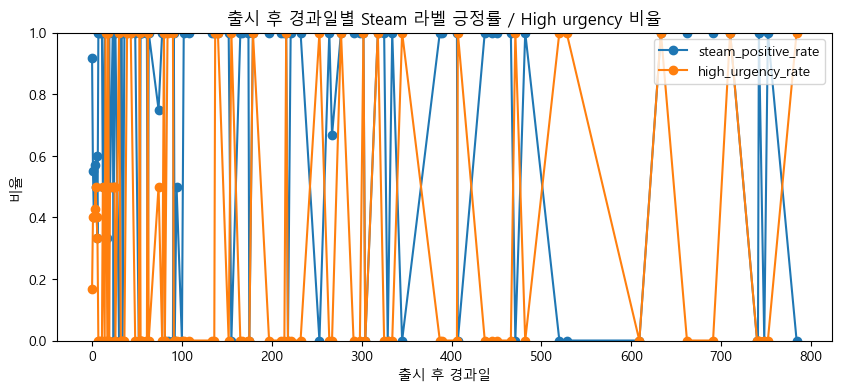

In [10]:
# ============================================================
# 5-1. 경과일별 리뷰 수와 반응 추세
# ============================================================

if "days_from_release" in df_game.columns and df_game["days_from_release"].notna().any():
    daily_summary = (
        df_game
        .dropna(subset=["days_from_release"])
        .assign(days_from_release=lambda d: d["days_from_release"].astype(int))
        .groupby("days_from_release")
        .agg(
            review_count=("recommendationid", "count"),
            steam_positive_rate=("steam_label_text", lambda s: s.eq("positive").mean()),
            high_urgency_rate=("urgency", lambda s: s.eq("high").mean()),
        )
        .reset_index()
        .sort_values("days_from_release")
    )

    display(daily_summary.head(30))

    if len(daily_summary) >= 2:
        ax = daily_summary.plot(
            x="days_from_release",
            y="review_count",
            kind="line",
            marker="o",
            figsize=(10, 4),
            legend=False
        )
        ax.set_title("출시 후 경과일별 리뷰 수")
        ax.set_xlabel("출시 후 경과일")
        ax.set_ylabel("리뷰 수")
        plt.show()

        ax = daily_summary.plot(
            x="days_from_release",
            y=["steam_positive_rate", "high_urgency_rate"],
            kind="line",
            marker="o",
            figsize=(10, 4)
        )
        ax.set_title("출시 후 경과일별 Steam 라벨 긍정률 / High urgency 비율")
        ax.set_xlabel("출시 후 경과일")
        ax.set_ylabel("비율")
        plt.ylim(0, 1)
        plt.show()
    else:
        print("경과일 종류가 1개라서 일자별 선 그래프는 생략합니다.")
else:
    print("days_from_release 컬럼이 없거나 비어 있어 경과일별 분석을 생략합니다.")


# 6. Steam 라벨과 LLM 감정 비교

Steam 추천/비추천 라벨과 LLM이 리뷰 본문에서 해석한 감정은 항상 일치하지 않는다.  
예를 들어 Steam에서는 추천 리뷰이지만, 본문에는 불편함이나 개선 요구가 함께 들어 있을 수 있다.

따라서 이 섹션에서는 Steam 라벨과 LLM 감정의 차이를 확인하여, 단순 추천 여부만으로 놓칠 수 있는 개선 요구를 살펴본다.


In [11]:
# ============================================================
# 6. Steam 라벨과 LLM 감정 비교
# ============================================================

steam_llm_crosstab = pd.crosstab(
    df_game["steam_label_text"],
    df_game["llm_sentiment"],
    margins=True
)

display(steam_llm_crosstab)

positive_but_not_positive = df_game[
    (df_game["steam_label_text"].eq("positive")) &
    (~df_game["llm_sentiment"].eq("positive"))
].copy()

negative_but_not_negative = df_game[
    (df_game["steam_label_text"].eq("negative")) &
    (~df_game["llm_sentiment"].eq("negative"))
].copy()

label_gap_summary = pd.DataFrame({
    "항목": [
        "Steam은 긍정이지만 LLM은 긍정이 아닌 리뷰",
        "Steam은 부정이지만 LLM은 부정이 아닌 리뷰",
    ],
    "리뷰 수": [
        len(positive_but_not_positive),
        len(negative_but_not_negative),
    ],
    "해석": [
        "게임을 추천하지만 불편함이나 개선 요구를 함께 말한 리뷰",
        "비추천이지만 일부 장점 또는 혼합 감정이 포함된 리뷰",
    ]
})

display(label_gap_summary)

review_cols = [
    "recommendationid",
    "review_datetime",
    "release_period",
    "playtime_at_review_hours",
    "steam_label_text",
    "llm_sentiment",
    "primary_issue",
    "urgency",
    "summary",
    "suggested_action",
]

print("Steam 긍정 리뷰 안의 개선 요구 예시")
display(positive_but_not_positive[[c for c in review_cols if c in positive_but_not_positive.columns]].head(10))


llm_sentiment,mixed,negative,neutral,positive,All
steam_label_text,,,,,
negative,3,61,0,0,64
positive,24,5,2,86,117
All,27,66,2,86,181


,항목,리뷰 수,해석
0,Steam은 긍정이지만 LLM은 긍정이 아닌 리뷰,31,게임을 추천하지만 불편함이나 개선 요구를 함께 말한 리뷰
1,Steam은 부정이지만 LLM은 부정이 아닌 리뷰,3,비추천이지만 일부 장점 또는 혼합 감정이 포함된 리뷰


Steam 긍정 리뷰 안의 개선 요구 예시


,recommendationid,review_datetime,release_period,playtime_at_review_hours,steam_label_text,llm_sentiment,primary_issue,urgency,summary,suggested_action
0,159990344,2024-03-06 19:49:16,D0-D30,0.416667,positive,mixed,optimization,medium,게임 자체는 흥미로우나 최적화가 아쉽고 우크라이나어 지원을 요청함.,"최적화 패치를 통해 프레임 드랍 및 성능 문제를 개선하고, 향후 업데이트 시 우크라이나어 현지화 추가를 고려하십시오."
2,159992435,2024-03-06 20:27:11,D0-D30,0.283333,positive,mixed,ui_ux,medium,게임은 좋으나 인트로 텍스트 속도가 너무 빠르고 물리 버그가 존재함.,"인트로 텍스트 가독성을 위해 속도를 늦추거나 일시 정지 기능을 추가하고, 보고된 물리 엔진 버그를 수정하십시오."
6,159997319,2024-03-06 21:58:04,D0-D30,0.166667,positive,mixed,bug,high,"게임 초반은 좋았으나, 동물원 구역에서 조명 관련 그래픽 글리치 버그가 발생함.","조명 관련 그래픽 글리치 현상을 조사하고, 특정 환경에서 발생하는 렌더링 오류를 수정하기 위한 패치를 배포하세요."
11,160003062,2024-03-06 23:58:33,D0-D30,0.133333,positive,mixed,graphics_audio,high,게임은 만족하지만 AMD GPU 사용 시 그래픽 설정이 낮음이 아닐 경우 화면에 색깔 빛이 번지는 그래픽 오류가 발생함.,"AMD GPU 환경에서 발생하는 그래픽 깨짐 현상(아티팩트)에 대한 원인을 파악하고, 드라이버 호환성 문제인지 엔진 설정 문제인지 확인하여 핫픽스를 배포하십시오."
18,160018892,2024-03-07 06:16:00,D0-D30,1.516667,positive,mixed,gameplay_loop,medium,"게임의 분위기와 독창적인 메커니즘은 훌륭하지만, 이동 수단인 발사대의 물리 엔진이 불안정하여 플레이 경험을 저해함.","물리 기반 발사대(launcher)의 정확도를 개선하거나, 사용자 경험을 위해 고정된 지점으로 이동하도록 로직을 수정하는 것을 고려하세요."
22,160035818,2024-03-07 13:26:31,D0-D30,7.833333,positive,mixed,gameplay_loop,high,"몬스터 디자인과 플래시 메커니즘은 좋으나, 퍼즐의 반복성과 적 AI 버그, 리스폰 시스템의 불편함이 지적되었습니다.","퍼즐의 다양성을 확보하고, 적의 AI 경로 탐색 버그 수정 및 벽 너머 공격 판정 문제를 해결하세요. 리스폰 지점 시스템 개선도 고려해야 합니다."
31,160067789,2024-03-07 23:10:53,D0-D30,4.133333,positive,mixed,gameplay_loop,high,"게임은 재미있으나 세이브 시스템, 적 AI, 무기 밸런스 등 개선할 점이 많음. 멀티플레이어 추가 희망.","세이브 시스템 개선(보스전 근처 체크포인트), 적 AI의 안전지대 캠핑 수정, 무기 충전 속도 밸런스 조정이 시급합니다. 멀티플레이어 추가는 장기적 로드맵으로 고려하세요."
36,160085087,2024-03-08 06:39:44,D0-D30,4.716667,positive,mixed,gameplay_loop,medium,비주얼은 훌륭하나 퍼즐과 게임플레이가 다소 아쉽고 공포 요소가 부족함. 1인 개발작임을 감안하면 무난함.,"퍼즐의 난이도와 재미를 개선하고, 공포 게임으로서의 정체성을 강화하기 위해 사운드 디자인이나 연출을 보강하는 업데이트를 고려하세요."
42,160116487,2024-03-08 17:03:02,D0-D30,6.083333,positive,mixed,bug,medium,"게임의 분위기와 몬스터 디자인은 훌륭하나, 몬스터 끼임 현상과 발사대 퍼즐의 물리적 불안정함이 게임 경험을 저해함.","몬스터의 충돌 판정(collision) 오류를 수정하고, 발사대 퍼즐의 물리 엔진 일관성을 개선하여 난이도를 조정할 필요가 있습니다."
48,160195710,2024-03-09 16:45:02,D0-D30,4.150000,positive,mixed,gameplay_loop,medium,"크리처 디자인과 분위기는 훌륭하나, 퍼즐의 반복성이 심해 게임의 완성도가 다소 아쉬움.",퍼즐의 다양성을 확보하고 반복적인 메커니즘을 개선하여 게임 플레이의 깊이를 더할 필요가 있음.


# 7. 유저가 좋아한 요소 분석

이 섹션에서는 유저가 긍정적으로 언급한 요소를 확인한다.  
단, `positive_praise`는 “재밌다”, “좋다”처럼 전반적 만족 표현에 가까워 구체적인 운영 전략으로 연결하기 어렵다.

따라서 강점 분석에서는 `positive_praise`를 제외하고, 그래픽/사운드, 콘텐츠, 조작감, 난이도처럼 실제 유지·강화 전략으로 연결 가능한 태그를 중심으로 확인한다.


,항목,값
0,positive_praise 제외 리뷰 수,100
1,positive_praise 제외 태그 수,101


,tag_category,issue_name_kor,positive_tag_count,affected_review_count,avg_playtime_hours,median_playtime_hours,representative_evidence
3,graphics_audio,그래픽/사운드,10,10,4.343333,3.941667,"visuals are spectacular / Monster designs are super cool / Graphics are good, atmosphere is great, soundtrack is mem..."
0,content_volume,콘텐츠 분량,3,3,8.722222,4.150000,"It's short, only about 4 hours to finish but that's perfectly fair for the price / let us explore after the game is ..."
1,difficulty,난이도,3,3,2.500000,3.100000,pretty hard game thats kinda good / lil confusing and hard sometimes / its not a easy game that i beat like in 2 days
2,gameplay_loop,게임플레이 루프,2,2,3.516667,3.516667,"dikejar-kejar monster yang mengerikan, lari nya lebih cepat dari sang karakter / gameplays good"
8,save_progression,저장/진행,2,2,10.375000,10.375000,"You can save at any point, and it only takes a few seconds to quit to the menu and reload your save. / save point te..."
4,multiplayer_network,멀티/네트워크,1,1,4.133333,4.133333,Multiplayer: This would be a cool game to play with friends
5,optimization,최적화,1,1,0.400000,0.400000,works well on my pretty simple laptop.
6,other,기타,1,1,6.450000,6.450000,농담 위주의 리뷰로 게임에 대한 실질적인 피드백이 없음
7,price_value,가격/가치,1,1,6.316667,6.316667,the game is still fun especially for the cost
9,story,스토리,1,1,0.900000,0.900000,story is the best 10/10


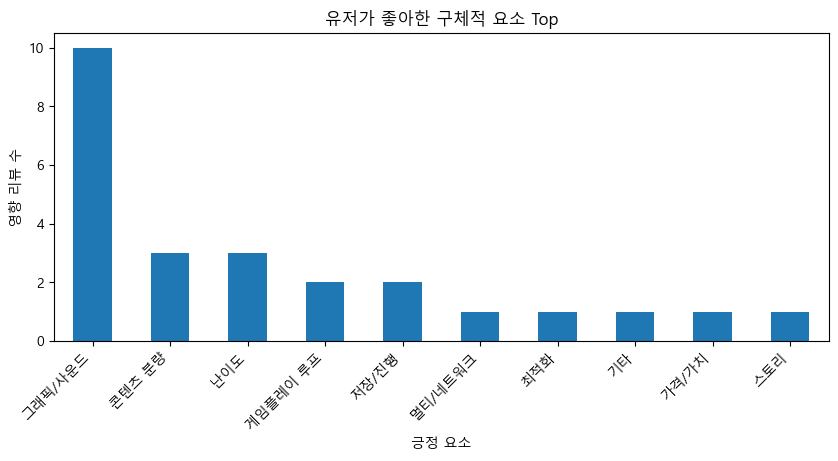

In [12]:
# ============================================================
# 7. 긍정 강점 분석
# ============================================================

pos_tags_all = df_game_tags[df_game_tags["tag_sentiment"].eq("positive")].copy()
positive_praise_tags = pos_tags_all[pos_tags_all["tag_category"].eq("positive_praise")].copy()

# positive_praise는 전반적 만족 표현이므로 구체적 강점 분석에서는 제외
pos_tags = pos_tags_all[~pos_tags_all["tag_category"].eq("positive_praise")].copy()

positive_praise_overview = pd.DataFrame({
    "항목": ["positive_praise 제외 리뷰 수", "positive_praise 제외 태그 수"],
    "값": [positive_praise_tags["recommendationid"].nunique(), len(positive_praise_tags)]
})

display(positive_praise_overview)

if pos_tags.empty:
    positive_strength_summary = pd.DataFrame()
    print("positive_praise를 제외하면 구체적인 긍정 태그가 없습니다.")
else:
    positive_strength_summary = (
        pos_tags
        .groupby(["tag_category", "issue_name_kor"], dropna=False)
        .agg(
            positive_tag_count=("tag_category", "count"),
            affected_review_count=("recommendationid", "nunique"),
            avg_playtime_hours=("playtime_at_review_hours", "mean"),
            median_playtime_hours=("playtime_at_review_hours", "median"),
            representative_evidence=("tag_evidence", lambda s: " / ".join(s.dropna().astype(str).head(3))),
        )
        .reset_index()
        .sort_values(["affected_review_count", "positive_tag_count"], ascending=False)
    )

    display(positive_strength_summary.head(TOP_N))

    ax = positive_strength_summary.head(TOP_N).set_index("issue_name_kor")["affected_review_count"].plot(
        kind="bar",
        figsize=(10, 4)
    )
    ax.set_title("유저가 좋아한 구체적 요소 Top")
    ax.set_xlabel("긍정 요소")
    ax.set_ylabel("영향 리뷰 수")
    plt.xticks(rotation=45, ha="right")
    plt.show()


# 8. 유저가 불만을 가진 요소 분석

출시 후 분석의 핵심은 **부정 리뷰에서 반복되는 문제를 찾는 것**이다.

여기서는 부정 태그를 기준으로 다음을 함께 확인한다.

| 항목 | 의미 |
|---|---|
| 부정 태그 수 | 해당 이슈가 얼마나 자주 언급되었는지 |
| 영향 리뷰 수 | 몇 개의 리뷰에서 이 문제가 나타났는지 |
| High urgency 리뷰 수 | 빠른 대응이 필요한 리뷰가 얼마나 있는지 |
| 평균 플레이타임 | 초반 이탈 문제인지, 누적 불만인지 |
| 대표 근거 | 실제 리뷰에서 나온 표현 |


,tag_category,issue_name_kor,negative_tag_count,affected_review_count,high_urgency_review_count,medium_urgency_review_count,short_exit_review_count,avg_playtime_hours,median_playtime_hours,total_votes_up,representative_evidence
7,gameplay_loop,게임플레이 루프,66,62,35,25,20,3.793434,2.191667,632.0,20 climbing frames that are uninteresting and tedious to solve. / 퍼즐 반복 과정에서 몬스터 공격 및 리셋 메커니즘이 불합리함 / 퍼즐 방식이 20번 반복되...
1,bug,버그,29,29,24,5,8,5.564943,3.450000,87.0,ran into a physics bug upon blasting the first wall / zoo part I had a weird bug where it made the whole screen like...
6,difficulty,난이도,28,28,12,14,5,4.729167,3.566667,234.0,"일부 퍼즐이 지나치게 어렵고 시행착오를 강요함 / tedious, awful and frustrating puzzles / puzzles became a bit repetitive"
3,control,조작감,16,16,9,7,3,4.303125,2.408333,107.0,"no control settings, sensitivity too fast / make the reload faster / planks bounce too far even when standing on the..."
13,save_progression,저장/진행,12,12,10,2,0,3.352778,3.408333,84.0,자동 저장 기능 부재로 인한 진행 상황 손실 발생 / boss fight teleports you miles away... no autosaves / gotten off the game forgetting t...
8,graphics_audio,그래픽/사운드,11,11,4,7,5,4.736364,1.183333,43.0,"on all graphics but low, I get a bunch of colored lights covering my screen / constant loud noises / unscary atmosphere"
10,other,기타,11,11,2,5,6,1.451515,0.950000,100.0,monster designs feel too similar (big mouth/sharp teeth) / mascot horror 장르에 대한 강한 거부감과 게임 품질에 대한 비판 / the design is...
11,performance,성능,9,9,8,1,3,2.600000,1.400000,24.0,lag is normal / runs like crap / runs at 20-25fps with high-end hardware
0,balance,밸런스,9,9,6,3,2,2.138889,1.783333,104.0,need to adjust some monster agro and monster speed / unplayable because of balancing issues / weapon took so long to...
15,ui_ux,UI/UX,8,8,5,2,4,2.004167,0.933333,31.0,"intro needs to be slowed down, hard to read / cancel Bloom o Bang without wasting bulb, hints for items, sensitivity..."


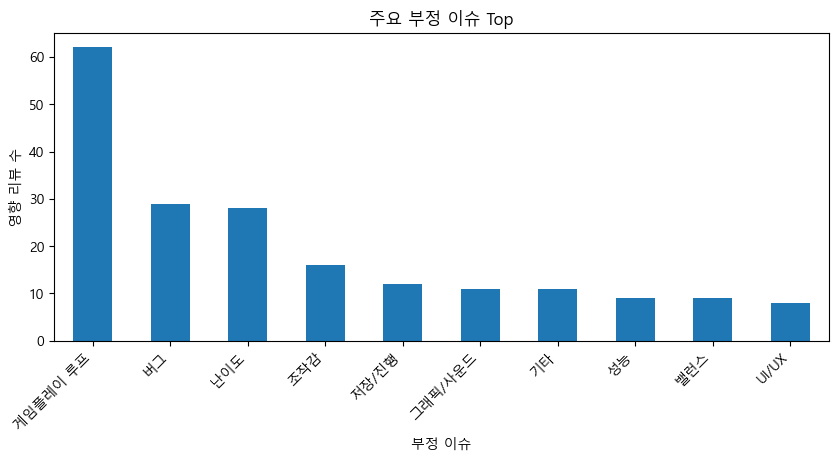

In [13]:
# ============================================================
# 8. 부정 이슈 분석
# ============================================================

neg_tags = df_game_tags[df_game_tags["tag_sentiment"].eq("negative")].copy()

if neg_tags.empty:
    negative_issue_summary = pd.DataFrame()
    print("부정 태그가 없습니다.")
else:
    negative_issue_summary = (
        neg_tags
        .groupby(["tag_category", "issue_name_kor"], dropna=False)
        .agg(
            negative_tag_count=("tag_category", "count"),
            affected_review_count=("recommendationid", "nunique"),
            high_urgency_review_count=("urgency", lambda s: s.eq("high").sum()),
            medium_urgency_review_count=("urgency", lambda s: s.eq("medium").sum()),
            short_exit_review_count=("playtime_bin", lambda s: s.eq("0~1시간").sum()),
            avg_playtime_hours=("playtime_at_review_hours", "mean"),
            median_playtime_hours=("playtime_at_review_hours", "median"),
            total_votes_up=("votes_up", "sum") if "votes_up" in neg_tags.columns else ("recommendationid", "count"),
            representative_evidence=("tag_evidence", lambda s: " / ".join(s.dropna().astype(str).head(3))),
        )
        .reset_index()
    )

    negative_issue_summary = negative_issue_summary.sort_values(
        ["affected_review_count", "high_urgency_review_count", "negative_tag_count"],
        ascending=False
    )

    display(negative_issue_summary.head(TOP_N))

    ax = negative_issue_summary.head(TOP_N).set_index("issue_name_kor")["affected_review_count"].plot(
        kind="bar",
        figsize=(10, 4)
    )
    ax.set_title("주요 부정 이슈 Top")
    ax.set_xlabel("부정 이슈")
    ax.set_ylabel("영향 리뷰 수")
    plt.xticks(rotation=45, ha="right")
    plt.show()


# 9. 플레이타임별 부정 원인

같은 부정 리뷰라도 플레이타임에 따라 의미가 다르다.

| 플레이타임 | 해석 |
|---|---|
| 0~1시간 | 첫인상, 튜토리얼, 조작, 최적화, 기대 불일치 문제 |
| 1~5시간 | 초반 플레이 경험, 반복성, 난이도, 진행 문제 |
| 5~20시간 | 중반 콘텐츠, 밸런스, 피로도, 버그 누적 |
| 20시간 이상 | 장기 플레이 유저의 후반 콘텐츠, 운영, 업데이트 불만 |


issue_name_kor,게임플레이 루프,버그,난이도,조작감,저장/진행,그래픽/사운드,기타,밸런스,성능,UI/UX
playtime_bin,,,,,,,,,,
0~1시간,20,8,5,3,0,5,6,2,3,4
1~5시간,36,13,16,9,11,3,5,7,5,3
5~20시간,8,6,6,3,1,2,0,0,1,1
20시간 이상,2,2,1,1,0,1,0,0,0,0


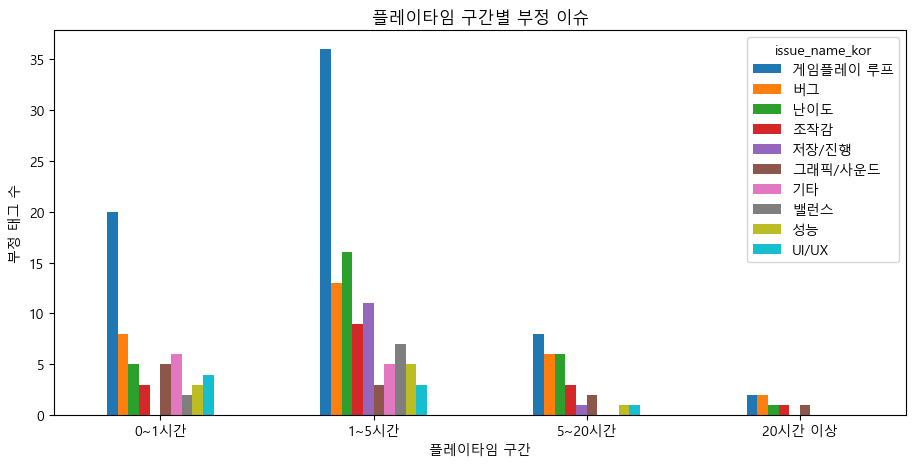

In [14]:
# ============================================================
# 9. 플레이타임별 부정 원인
# ============================================================

if neg_tags.empty:
    playtime_issue_table = pd.DataFrame()
    print("부정 태그가 없어 플레이타임별 부정 원인 분석을 생략합니다.")
else:
    playtime_issue_table = pd.crosstab(
        neg_tags["playtime_bin"],
        neg_tags["issue_name_kor"]
    )

    # 전체 빈도가 높은 이슈만 보기 좋게 정렬
    top_issue_cols = playtime_issue_table.sum(axis=0).sort_values(ascending=False).head(TOP_N).index
    playtime_issue_table = playtime_issue_table.reindex(PLAYTIME_LABELS).fillna(0)
    playtime_issue_table = playtime_issue_table[top_issue_cols]

    display(playtime_issue_table)

    ax = playtime_issue_table.plot(kind="bar", figsize=(11, 5))
    ax.set_title("플레이타임 구간별 부정 이슈")
    ax.set_xlabel("플레이타임 구간")
    ax.set_ylabel("부정 태그 수")
    plt.xticks(rotation=0)
    plt.show()


# 10. 패치·운영 우선 검토 이슈

출시 후 분석의 최종 목적은 리뷰에서 반복적으로 나타난 문제를 정리하고, 개발사가 어떤 이슈를 먼저 확인해야 하는지 판단할 수 있도록 돕는 것이다.

본 보고서에서는 임의의 종합 점수를 만들지 않고, 다음 기준을 나누어 확인한다.

1. 여러 리뷰에서 반복적으로 언급된 이슈
2. LLM이 High urgency로 분류한 리뷰가 많은 이슈
3. 0~1시간 플레이타임 구간에서 나타난 초기 이탈 관련 이슈
4. 출시 초반 구간에서 집중적으로 나타난 이슈

긴급도는 별도 수식으로 계산한 값이 아니라, LLM이 리뷰 본문을 읽고 분류한 값이다.  
따라서 High urgency 비율은 절대적인 장애 지표가 아니라, 유저가 느낀 문제의 심각도를 비교하기 위한 보조 기준으로 해석한다.

| 긴급도 | 해석 |
|---|---|
| high | 게임 진행 방해, 반복적 버그, 저장 문제, 심각한 불편처럼 빠른 확인이 필요한 문제 |
| medium | 불편함은 있으나 즉시 치명적이라고 보기는 어려운 문제 |
| low | 취향 차이, 가벼운 개선 요청, 단순 아쉬움에 가까운 문제 |


In [15]:
# ============================================================
# 10. 패치·운영 우선 검토 이슈
# ============================================================

# 패치·운영 검토는 전체 태그 중에서
# 1) 부정 태그이거나
# 2) LLM 감정이 negative/mixed이거나
# 3) urgency가 high인 태그를 중심으로 확인한다.
# 단, positive_praise는 전반적 만족 표현이므로 패치 대상 이슈에서는 제외한다.

priority_base = df_game_tags.copy()

if priority_base.empty:
    issue_priority_summary = pd.DataFrame()
    issue_action_summary = pd.DataFrame()
    issue_priority_with_action = pd.DataFrame()
    patch_priority = pd.DataFrame()
    operation_suggestion_table = pd.DataFrame()
    top_issue_evidence = pd.DataFrame()
    print("분석할 이슈 태그가 없어 패치·운영 우선 검토 이슈 분석을 생략합니다.")
else:
    # ------------------------------------------------------------
    # 1) 분석용 플래그 생성
    # ------------------------------------------------------------
    priority_base["urgency"] = priority_base["urgency"].astype(str).str.lower().str.strip()
    priority_base["llm_sentiment"] = priority_base["llm_sentiment"].astype(str).str.lower().str.strip()
    priority_base["tag_sentiment"] = priority_base["tag_sentiment"].astype(str).str.lower().str.strip()
    priority_base["release_period"] = priority_base["release_period"].astype(str).str.upper().str.strip()

    priority_base["is_negative_tag"] = priority_base["tag_sentiment"].eq("negative")
    priority_base["is_negative_or_mixed_review"] = priority_base["llm_sentiment"].isin(["negative", "mixed"])
    priority_base["is_high_urgency"] = priority_base["urgency"].eq("high")
    priority_base["is_initial_period"] = priority_base["release_period"].isin(["D0-D7", "D8-D30", "D0-D30"])

    if "playtime_at_review_hours" in priority_base.columns:
        priority_base["is_early_exit"] = priority_base["playtime_at_review_hours"].le(1)
    else:
        priority_base["is_early_exit"] = False

    # 조건별 리뷰 수를 중복 없이 세기 위한 보조 컬럼
    priority_base["high_urgency_review_id"] = priority_base["recommendationid"].where(priority_base["is_high_urgency"])
    priority_base["early_exit_review_id"] = priority_base["recommendationid"].where(priority_base["is_early_exit"])
    priority_base["initial_period_review_id"] = priority_base["recommendationid"].where(priority_base["is_initial_period"])
    priority_base["negative_or_mixed_review_id"] = priority_base["recommendationid"].where(priority_base["is_negative_or_mixed_review"])

    # 패치·운영 검토 대상만 필터링
    patch_focus_tags = priority_base[
        (
            priority_base["is_negative_tag"]
            | priority_base["is_negative_or_mixed_review"]
            | priority_base["is_high_urgency"]
        )
        & (~priority_base["tag_category"].eq("positive_praise"))
    ].copy()

    if patch_focus_tags.empty:
        issue_priority_summary = pd.DataFrame()
        issue_action_summary = pd.DataFrame()
        issue_priority_with_action = pd.DataFrame()
        patch_priority = pd.DataFrame()
        operation_suggestion_table = pd.DataFrame()
        top_issue_evidence = pd.DataFrame()
        print("패치·운영 우선 검토 대상으로 볼 부정/혼합/High urgency 이슈가 없습니다.")
    else:
        # ------------------------------------------------------------
        # 2) 이슈별 반복성·긴급성·초기 이탈·출시 초반 집중도 집계
        # ------------------------------------------------------------
        issue_priority_summary = (
            patch_focus_tags
            .groupby(["tag_category", "issue_name_kor"], dropna=False)
            .agg(
                영향_리뷰_수=("recommendationid", "nunique"),
                이슈_태그_수=("tag_category", "size"),
                부정_태그_수=("is_negative_tag", "sum"),
                부정_혼합_리뷰_수=("negative_or_mixed_review_id", "nunique"),
                High_urgency_리뷰_수=("high_urgency_review_id", "nunique"),
                초기_이탈_리뷰_수=("early_exit_review_id", "nunique"),
                출시초기_리뷰_수=("initial_period_review_id", "nunique"),
                평균_플레이타임=("playtime_at_review_hours", "mean"),
                중앙값_플레이타임=("playtime_at_review_hours", "median"),
                유용함_투표_합계=("votes_up", "sum"),
                대표_근거=("tag_evidence", lambda s: " / ".join(s.dropna().astype(str).head(3))),
            )
            .reset_index()
        )

        issue_priority_summary["High_urgency_비율"] = (
            issue_priority_summary["High_urgency_리뷰_수"]
            / issue_priority_summary["영향_리뷰_수"]
            * 100
        ).round(1)

        issue_priority_summary["초기_이탈_비율"] = (
            issue_priority_summary["초기_이탈_리뷰_수"]
            / issue_priority_summary["영향_리뷰_수"]
            * 100
        ).round(1)

        issue_priority_summary["출시초기_비율"] = (
            issue_priority_summary["출시초기_리뷰_수"]
            / issue_priority_summary["영향_리뷰_수"]
            * 100
        ).round(1)

        issue_priority_summary["평균_플레이타임"] = issue_priority_summary["평균_플레이타임"].round(2)
        issue_priority_summary["중앙값_플레이타임"] = issue_priority_summary["중앙값_플레이타임"].round(2)
        issue_priority_summary["유용함_투표_합계"] = issue_priority_summary["유용함_투표_합계"].fillna(0).round(0).astype(int)

        # 임의 점수를 만들지 않고, 긴급성 → 반복성 → 초기 이탈 → 출시 초반 집중도 순으로 정렬
        issue_priority_summary = issue_priority_summary.sort_values(
            [
                "High_urgency_리뷰_수",
                "영향_리뷰_수",
                "초기_이탈_리뷰_수",
                "출시초기_리뷰_수",
                "부정_태그_수",
            ],
            ascending=False
        )

        print("10-1. 패치·운영 우선 검토 이슈 표")
        display(issue_priority_summary.head(TOP_N))

        # ------------------------------------------------------------
        # 3) suggested_action 연결
        # ------------------------------------------------------------
        action_base = df_game[["recommendationid", "suggested_action"]].drop_duplicates()

        action_tags = patch_focus_tags.merge(
            action_base,
            on="recommendationid",
            how="left"
        )

        urgency_rank = {"high": 0, "medium": 1, "low": 2}
        action_tags["_urgency_rank"] = action_tags["urgency"].map(urgency_rank).fillna(9)

        sort_cols = ["tag_category", "issue_name_kor", "_urgency_rank"]
        ascending = [True, True, True]

        if "votes_up" in action_tags.columns:
            sort_cols.append("votes_up")
            ascending.append(False)

        issue_action_summary = (
            action_tags
            .dropna(subset=["suggested_action"])
            .drop_duplicates(["tag_category", "issue_name_kor", "suggested_action"])
            .sort_values(sort_cols, ascending=ascending)
            .groupby(["tag_category", "issue_name_kor"], dropna=False)
            .head(3)
            .groupby(["tag_category", "issue_name_kor"], dropna=False)["suggested_action"]
            .apply(lambda s: " / ".join(s.dropna().astype(str)))
            .reset_index()
            .rename(columns={"suggested_action": "패치_운영_제안"})
        )

        issue_priority_with_action = issue_priority_summary.merge(
            issue_action_summary,
            on=["tag_category", "issue_name_kor"],
            how="left"
        )

        # ------------------------------------------------------------
        # 4) 대응 유형 분류
        # ------------------------------------------------------------
        immediate_check_categories = ["bug", "crash", "performance", "optimization", "save_progression"]
        short_term_categories = ["gameplay_loop", "difficulty", "control", "ui_ux", "balance", "price_value", "progression_grind"]
        long_term_categories = ["content_volume", "multiplayer_network", "developer_communication", "translation_localization", "story", "monetization", "other"]

        def classify_response_type(tag_category):
            if tag_category in immediate_check_categories:
                return "즉시 확인"
            if tag_category in short_term_categories:
                return "단기 개선"
            if tag_category in long_term_categories:
                return "장기 검토"
            return "검토 필요"

        response_recommendation = {
            "즉시 확인": "플레이 방해 요소, 저장 문제, 버그, 성능 문제를 먼저 재현·확인한다.",
            "단기 개선": "반복 플레이 구조, 난이도, 조작감, UI/UX처럼 경험 품질을 낮추는 요소를 개선한다.",
            "장기 검토": "콘텐츠 확장, 멀티플레이, 스토리 보강처럼 업데이트 로드맵 수준에서 검토한다.",
            "검토 필요": "리뷰 원문과 태그 근거를 추가 확인한 뒤 대응 방향을 정한다.",
        }

        issue_priority_with_action["대응_구분"] = issue_priority_with_action["tag_category"].apply(classify_response_type)
        issue_priority_with_action["제안_방향"] = issue_priority_with_action["대응_구분"].map(response_recommendation)

        # 뒤쪽 요약에서 사용할 이름
        patch_priority = issue_priority_with_action.copy()

        display_cols = [
            "대응_구분",
            "issue_name_kor",
            "영향_리뷰_수",
            "High_urgency_리뷰_수",
            "High_urgency_비율",
            "초기_이탈_리뷰_수",
            "출시초기_리뷰_수",
            "패치_운영_제안",
        ]

        print("10-2. 이슈별 패치·운영 제안")
        display(issue_priority_with_action[display_cols].head(TOP_N))

        operation_suggestion_table = (
            issue_priority_with_action
            .groupby("대응_구분", dropna=False)
            .agg(
                주요_이슈=("issue_name_kor", lambda s: ", ".join(s.dropna().astype(str).head(5))),
                이슈_수=("issue_name_kor", "count"),
                영향_리뷰_수_합계=("영향_리뷰_수", "sum"),
                High_urgency_리뷰_수_합계=("High_urgency_리뷰_수", "sum"),
                제안_방향=("제안_방향", "first"),
            )
            .reset_index()
        )

        response_order = {"즉시 확인": 0, "단기 개선": 1, "장기 검토": 2, "검토 필요": 3}
        operation_suggestion_table["_order"] = operation_suggestion_table["대응_구분"].map(response_order).fillna(99)
        operation_suggestion_table = operation_suggestion_table.sort_values("_order").drop(columns="_order")

        print("10-3. 대응 유형별 운영 제안")
        display(operation_suggestion_table)

        # 유지·강화 후보는 긍정 강점 분석 결과에서 별도로 확인
        if "positive_strength_summary" in globals() and not positive_strength_summary.empty:
            maintain_strength_table = positive_strength_summary[
                ["issue_name_kor", "affected_review_count", "positive_tag_count", "representative_evidence"]
            ].head(5).copy()
            maintain_strength_table = maintain_strength_table.rename(columns={
                "issue_name_kor": "유지_강화_후보",
                "affected_review_count": "영향_리뷰_수",
                "positive_tag_count": "긍정_태그_수",
                "representative_evidence": "대표_근거",
            })

            print("10-4. 유지·강화 후보")
            display(maintain_strength_table)
        else:
            maintain_strength_table = pd.DataFrame()

        # ------------------------------------------------------------
        # 5) 최상위 이슈의 실제 근거 문장 확인
        # ------------------------------------------------------------
        top_issue_category = issue_priority_summary.iloc[0]["tag_category"]
        top_issue_name = issue_priority_summary.iloc[0]["issue_name_kor"]

        evidence_sort_cols = ["is_high_urgency"]
        evidence_ascending = [False]
        if "votes_up" in patch_focus_tags.columns:
            evidence_sort_cols.append("votes_up")
            evidence_ascending.append(False)
        if "playtime_at_review_hours" in patch_focus_tags.columns:
            evidence_sort_cols.append("playtime_at_review_hours")
            evidence_ascending.append(True)

        top_issue_evidence = (
            patch_focus_tags[patch_focus_tags["tag_category"].eq(top_issue_category)]
            .sort_values(evidence_sort_cols, ascending=evidence_ascending)
            [
                [
                    "game_name",
                    "issue_name_kor",
                    "urgency",
                    "llm_sentiment",
                    "release_period",
                    "playtime_at_review_hours",
                    "tag_evidence",
                ]
            ]
            .head(5)
        )

        print(f"10-5. 대표 리뷰 근거 확인: {top_issue_name}")
        display(top_issue_evidence)


10-1. 패치·운영 우선 검토 이슈 표


,tag_category,issue_name_kor,영향_리뷰_수,이슈_태그_수,부정_태그_수,부정_혼합_리뷰_수,High_urgency_리뷰_수,초기_이탈_리뷰_수,출시초기_리뷰_수,평균_플레이타임,중앙값_플레이타임,유용함_투표_합계,대표_근거,High_urgency_비율,초기_이탈_비율,출시초기_비율
7,gameplay_loop,게임플레이 루프,64,68,66,54,32,17,38,3.76,2.19,632,20 climbing frames that are uninteresting and tedious to solve. / 퍼즐 반복 과정에서 몬스터 공격 및 리셋 메커니즘이 불합리함 / 퍼즐 방식이 20번 반복되...,50.0,26.6,59.4
1,bug,버그,29,29,29,24,24,8,17,5.56,3.45,87,ran into a physics bug upon blasting the first wall / zoo part I had a weird bug where it made the whole screen like...,82.8,27.6,58.6
6,difficulty,난이도,30,30,28,22,12,6,17,4.66,3.57,234,"일부 퍼즐이 지나치게 어렵고 시행착오를 강요함 / tedious, awful and frustrating puzzles / challenging your brain",40.0,20.0,56.7
14,save_progression,저장/진행,12,12,12,7,10,0,6,3.35,3.41,84,자동 저장 기능 부재로 인한 진행 상황 손실 발생 / boss fight teleports you miles away... no autosaves / gotten off the game forgetting t...,83.3,0.0,50.0
3,control,조작감,16,16,16,12,9,3,5,4.30,2.41,107,"no control settings, sensitivity too fast / make the reload faster / planks bounce too far even when standing on the...",56.2,18.8,31.2
12,performance,성능,9,9,9,8,8,3,4,2.60,1.40,24,lag is normal / runs like crap / runs at 20-25fps with high-end hardware,88.9,33.3,44.4
8,graphics_audio,그래픽/사운드,18,18,11,17,7,7,9,4.61,3.00,60,"on all graphics but low, I get a bunch of colored lights covering my screen / monsters designs are really good and v...",38.9,38.9,50.0
17,ui_ux,UI/UX,9,9,8,6,6,4,6,2.02,1.23,31,"intro needs to be slowed down, hard to read / cancel Bloom o Bang without wasting bulb, hints for items, sensitivity...",66.7,44.4,66.7
0,balance,밸런스,9,9,9,6,6,2,7,2.14,1.78,104,need to adjust some monster agro and monster speed / unplayable because of balancing issues / weapon took so long to...,66.7,22.2,77.8
11,other,기타,13,13,11,11,2,8,4,1.31,0.78,103,monster designs feel too similar (big mouth/sharp teeth) / mascot horror 장르에 대한 강한 거부감과 게임 품질에 대한 비판 / the design is...,15.4,61.5,30.8


10-2. 이슈별 패치·운영 제안


,대응_구분,issue_name_kor,영향_리뷰_수,High_urgency_리뷰_수,High_urgency_비율,초기_이탈_리뷰_수,출시초기_리뷰_수,패치_운영_제안
0,단기 개선,게임플레이 루프,64,32,50.0,17,38,"퍼즐의 난이도 곡선을 재조정하고, 시행착오 시 리셋 페널티를 완화하세요. 특히 퍼즐 수행 중 몬스터의 공격 판정 범위를 수정하여 불합리한 죽음을 방지해야 합니다. / 세이브 시스템 개선(보스전 근처 체크포인트..."
1,즉시 확인,버그,29,24,82.8,8,17,"플랫폼 점프 판정 및 이동 메커니즘을 개선하고, 안전 구역 내 몬스터 피격 판정 버그를 수정하여 플레이어의 불쾌감을 줄여야 합니다. / 게임의 전반적인 템포를 개선하고, 세이브 시스템(자동 저장 기능)을 추가..."
2,단기 개선,난이도,30,12,40.0,6,17,"퍼즐의 난이도 곡선을 재조정하고, 시행착오 시 리셋 페널티를 완화하세요. 특히 퍼즐 수행 중 몬스터의 공격 판정 범위를 수정하여 불합리한 죽음을 방지해야 합니다. / 세이브 시스템 개선(보스전 근처 체크포인트..."
3,즉시 확인,저장/진행,12,10,83.3,0,6,"세이브 시스템 개선(보스전 근처 체크포인트), 적 AI의 안전지대 캠핑 수정, 무기 충전 속도 밸런스 조정이 시급합니다. 멀티플레이어 추가는 장기적 로드맵으로 고려하세요. / 게임의 전반적인 템포를 개선하고,..."
4,단기 개선,조작감,16,9,56.2,3,5,"플랫폼 점프 판정 및 이동 메커니즘을 개선하고, 안전 구역 내 몬스터 피격 판정 버그를 수정하여 플레이어의 불쾌감을 줄여야 합니다. / 적의 이동 속도 조정, 조명 아이템의 가시성 개선, 무기 재장전 속도 상..."
5,즉시 확인,성능,9,8,88.9,3,4,"퍼즐의 재미 요소 보강, 특정 구역의 최적화 작업, 라이트 건 메커니즘의 다양화, 그리고 AI 행동 패턴 개선을 통해 게임의 몰입감과 공포 요소를 강화할 필요가 있습니다. / 입력 지연 및 프레임 드랍 현상을..."
6,검토 필요,그래픽/사운드,18,7,38.9,7,9,"퍼즐의 재미 요소 보강, 특정 구역의 최적화 작업, 라이트 건 메커니즘의 다양화, 그리고 AI 행동 패턴 개선을 통해 게임의 몰입감과 공포 요소를 강화할 필요가 있습니다. / 반복적인 상호작용(판자 밀기) 개..."
7,단기 개선,UI/UX,9,6,66.7,4,6,"퍼즐의 다양성을 확보하고, 적의 AI 경로 탐색 버그 수정 및 벽 너머 공격 판정 문제를 해결하세요. 리스폰 지점 시스템 개선도 고려해야 합니다. / 튜토리얼의 지시 사항과 실제 게임 메커니즘 간의 불일치를 ..."
8,단기 개선,밸런스,9,6,66.7,2,7,"세이브 시스템 개선(보스전 근처 체크포인트), 적 AI의 안전지대 캠핑 수정, 무기 충전 속도 밸런스 조정이 시급합니다. 멀티플레이어 추가는 장기적 로드맵으로 고려하세요. / 퍼즐 위주의 단조로운 게임 플레이..."
9,장기 검토,기타,13,2,15.4,8,4,"퍼즐의 재미 요소 보강, 특정 구역의 최적화 작업, 라이트 건 메커니즘의 다양화, 그리고 AI 행동 패턴 개선을 통해 게임의 몰입감과 공포 요소를 강화할 필요가 있습니다. / Windows 10 환경에서의 최..."


10-3. 대응 유형별 운영 제안


,대응_구분,주요_이슈,이슈_수,영향_리뷰_수_합계,High_urgency_리뷰_수_합계,제안_방향
3,즉시 확인,"버그, 저장/진행, 성능, 크래시, 최적화",5,57,44,"플레이 방해 요소, 저장 문제, 버그, 성능 문제를 먼저 재현·확인한다."
1,단기 개선,"게임플레이 루프, 난이도, 조작감, UI/UX, 밸런스",6,131,67,"반복 플레이 구조, 난이도, 조작감, UI/UX처럼 경험 품질을 낮추는 요소를 개선한다."
2,장기 검토,"기타, 스토리, 개발사 소통, 멀티/네트워크, 콘텐츠 분량",6,25,6,"콘텐츠 확장, 멀티플레이, 스토리 보강처럼 업데이트 로드맵 수준에서 검토한다."
0,검토 필요,그래픽/사운드,1,18,7,리뷰 원문과 태그 근거를 추가 확인한 뒤 대응 방향을 정한다.


10-4. 유지·강화 후보


,유지_강화_후보,영향_리뷰_수,긍정_태그_수,대표_근거
3,그래픽/사운드,10,10,"visuals are spectacular / Monster designs are super cool / Graphics are good, atmosphere is great, soundtrack is mem..."
0,콘텐츠 분량,3,3,"It's short, only about 4 hours to finish but that's perfectly fair for the price / let us explore after the game is ..."
1,난이도,3,3,pretty hard game thats kinda good / lil confusing and hard sometimes / its not a easy game that i beat like in 2 days
2,게임플레이 루프,2,2,"dikejar-kejar monster yang mengerikan, lari nya lebih cepat dari sang karakter / gameplays good"
8,저장/진행,2,2,"You can save at any point, and it only takes a few seconds to quit to the menu and reload your save. / save point te..."


10-5. 대표 리뷰 근거 확인: 게임플레이 루프


,game_name,issue_name_kor,urgency,llm_sentiment,release_period,playtime_at_review_hours,tag_evidence
23,Zoonomaly,게임플레이 루프,high,negative,D0-D30,3.533333,퍼즐 반복 과정에서 몬스터 공격 및 리셋 메커니즘이 불합리함
63,Zoonomaly,게임플레이 루프,high,mixed,D0-D30,4.133333,"enemies would camp the ""safe zones"""
111,Zoonomaly,게임플레이 루프,high,negative,D0-D30,1.783333,"puzzles are repetitive, and uninteresting; nothing in between puzzles"
335,Zoonomaly,게임플레이 루프,high,negative,D181+,3.666667,"Charging your tool, waiting for planks to move, waiting for platforms to move, waiting for enemies to screw off"
86,Zoonomaly,게임플레이 루프,high,negative,D0-D30,1.966667,"without bulb or light, you cant see anything"


## 10-1. 해석 방법

위 표는 “절대적인 패치 순위표”가 아니라, 패치 회의에서 먼저 확인할 후보 이슈를 정리한 것이다.

- `영향 리뷰 수`가 높으면 여러 유저가 반복적으로 언급한 문제일 가능성이 높다.
- `High urgency 리뷰 수`가 높으면 유저가 심각하게 느낀 문제일 가능성이 높다.
- `초기 이탈 리뷰 수`가 높으면 첫인상, 조작, 튜토리얼, 진입 장벽 문제와 연결될 수 있다.
- `출시초기 리뷰 수`가 높으면 출시 직후 평가 흐름에 영향을 줬을 가능성이 있다.

따라서 실제 패치 방향은 단일 순위로 결정하기보다, `즉시 확인`, `단기 개선`, `장기 검토`, `유지·강화`처럼 대응 유형으로 나누어 검토하는 것이 적절하다.


# 11. 대표 리뷰 요약 및 개선 제안 확인

정량 집계만으로는 실제 유저 불만의 맥락을 놓칠 수 있다.  
따라서 긴급도가 높거나 부정/혼합 감정으로 분류된 리뷰를 직접 확인한다.


In [16]:
# ============================================================
# 11. 대표 리뷰 요약 및 개선 제안
# ============================================================

urgency_rank = {"high": 0, "medium": 1, "low": 2}

representative_reviews = df_game[
    df_game["llm_sentiment"].isin(["negative", "mixed"]) | df_game["urgency"].eq("high")
].copy()

representative_reviews["_urgency_rank"] = representative_reviews["urgency"].map(urgency_rank).fillna(9)

sort_cols = ["_urgency_rank"]
if "votes_up" in representative_reviews.columns:
    sort_cols.append("votes_up")

representative_reviews = representative_reviews.sort_values(
    sort_cols,
    ascending=[True] + [False] * (len(sort_cols) - 1)
)

representative_cols = [
    "recommendationid",
    "review_datetime",
    "release_period",
    "playtime_at_review_hours",
    "steam_label_text",
    "llm_sentiment",
    "primary_issue",
    "urgency",
    "summary",
    "suggested_action",
]

display(representative_reviews[[c for c in representative_cols if c in representative_reviews.columns]].head(TOP_N))


,recommendationid,review_datetime,release_period,playtime_at_review_hours,steam_label_text,llm_sentiment,primary_issue,urgency,summary,suggested_action
12,160005016,2024-03-07 00:40:23,D0-D30,3.533333,negative,negative,difficulty,high,"시각적 완성도는 높으나, 불합리한 퍼즐 난이도와 반복적인 리셋 메커니즘으로 인해 게임의 재미가 반감됨.","퍼즐의 난이도 곡선을 재조정하고, 시행착오 시 리셋 페널티를 완화하세요. 특히 퍼즐 수행 중 몬스터의 공격 판정 범위를 수정하여 불합리한 죽음을 방지해야 합니다."
31,160067789,2024-03-07 23:10:53,D0-D30,4.133333,positive,mixed,gameplay_loop,high,"게임은 재미있으나 세이브 시스템, 적 AI, 무기 밸런스 등 개선할 점이 많음. 멀티플레이어 추가 희망.","세이브 시스템 개선(보스전 근처 체크포인트), 적 AI의 안전지대 캠핑 수정, 무기 충전 속도 밸런스 조정이 시급합니다. 멀티플레이어 추가는 장기적 로드맵으로 고려하세요."
114,166040747,2024-05-25 15:57:09,D31-D90,1.016667,positive,negative,control,high,기대했던 게임이나 점프 메커니즘의 불편함과 안전 구역 내 몬스터 피격 버그로 인해 게임 플레이가 매우 어렵고 불만족스러움.,"플랫폼 점프 판정 및 이동 메커니즘을 개선하고, 안전 구역 내 몬스터 피격 판정 버그를 수정하여 플레이어의 불쾌감을 줄여야 합니다."
50,160198241,2024-03-09 17:22:11,D0-D30,1.783333,negative,negative,gameplay_loop,high,"퍼즐이 너무 반복적이고 지루하며, 기대했던 호러 요소보다 퍼즐 비중이 지나치게 높아 실망스러움.","퍼즐 위주의 단조로운 게임 플레이를 개선하고, 호러 요소와 탐험의 비중을 높여 게임의 몰입감을 강화할 필요가 있음."
161,192906275,2025-04-17 00:29:59,D181+,3.666667,negative,negative,gameplay_loop,high,"반복적인 대기 시간, 단조로운 적 AI, 세이브 시스템 부재 및 소프트락 버그로 인해 게임 플레이가 지루하고 불만족스러움.","게임의 전반적인 템포를 개선하고, 세이브 시스템(자동 저장 기능)을 추가하여 진행 상황 손실을 방지하세요. 또한 적 AI의 행동 패턴을 다양화하고 버그 및 소프트락 현상을 수정해야 합니다."
39,160096165,2024-03-08 11:25:48,D0-D30,1.966667,negative,negative,difficulty,high,"게임 난이도가 너무 높고, 조명 부족, 느린 재장전, 안전 구역에서의 적 인식 문제로 인해 플레이가 불쾌함.","적의 이동 속도 조정, 조명 아이템의 가시성 개선, 무기 재장전 속도 상향, 안전 구역 내 적의 인식 범위 제한을 검토하세요."
43,160123609,2024-03-08 18:53:42,D0-D30,3.450000,negative,negative,gameplay_loop,high,발사대 퍼즐의 일관성 없는 물리 엔진과 인클로저 밖까지 공격이 판정되는 버그로 인해 게임 플레이가 매우 불만족스러움.,"발사대 퍼즐의 물리 연산을 고정값으로 수정하여 RNG 요소를 제거하고, 인클로저 외부로 판정이 새어 나가는 버그를 우선적으로 수정해야 합니다."
84,161715865,2024-03-29 10:34:35,D0-D30,0.200000,positive,mixed,crash,high,게임이 기대되지만 튜토리얼 이후 맵 로딩 시 프리징 현상으로 플레이 불가함.,맵 로딩 시 발생하는 프리징 현상에 대한 로그 분석 및 최적화 패치 필요. 사양별 호환성 체크리스트 제공 권장.
166,197740864,2025-06-20 23:02:40,D181+,3.916667,negative,negative,gameplay_loop,high,레벨 디자인과 적 AI 문제로 인해 공포감보다는 좌절감만 느껴지는 '레이지 게임' 같다는 비판.,"레벨 디자인과 적 AI의 밸런스를 재검토하십시오. 공포 게임으로서의 정체성을 살릴 수 있도록 난이도 곡선을 조정하고, 플레이어에게 불합리한 좌절감을 주는 요소들을 개선할 필요가 있습니다."
168,201684466,2025-08-08 05:49:17,D181+,2.850000,negative,negative,gameplay_loop,high,"퍼즐의 재미 부족, 최적화 문제, 반복적인 메커니즘, AI의 낮은 지능으로 인한 공포감 저하를 지적하며, 시각적 디자인은 긍정적으로 평가했습니다.","퍼즐의 재미 요소 보강, 특정 구역의 최적화 작업, 라이트 건 메커니즘의 다양화, 그리고 AI 행동 패턴 개선을 통해 게임의 몰입감과 공포 요소를 강화할 필요가 있습니다."


# 12. 보고서용 요약

In [17]:
# ============================================================
# 12. 보고서용 요약 작성에 필요한 핵심 값 확인
# ============================================================

report_summary_check = pd.DataFrame({
    "항목": [
        "게임명",
        "appid",
        "분석 리뷰 수",
        "분석 태그 수",
        "분석 표본 내 Steam 라벨 긍정률",
        "LLM 긍정률",
        "LLM 부정+혼합 비율",
        "High urgency 비율",
    ],
    "값": [
        selected_game_name,
        selected_appid,
        f"{len(df_game):,}개",
        f"{len(df_game_tags):,}개",
        pct(steam_positive_rate),
        pct(llm_positive_rate),
        pct(llm_negative_mixed_rate),
        pct(high_urgency_rate),
    ]
})

display(report_summary_check)

print("구체적 긍정 요소 Top")
if "positive_strength_summary" in globals() and not positive_strength_summary.empty:
    display(
        positive_strength_summary[
            [
                "issue_name_kor",
                "affected_review_count",
                "positive_tag_count",
                "representative_evidence",
            ]
        ].head(5)
    )
else:
    print("구체적 긍정 태그가 없습니다.")

print("부정 이슈 Top")
if "negative_issue_summary" in globals() and not negative_issue_summary.empty:
    display(
        negative_issue_summary[
            [
                "issue_name_kor",
                "affected_review_count",
                "negative_tag_count",
                "high_urgency_review_count",
                "short_exit_review_count",
                "representative_evidence",
            ]
        ].head(5)
    )
else:
    print("부정 태그가 없습니다.")

print("패치·운영 우선 검토 이슈 Top")
if "patch_priority" in globals() and not patch_priority.empty:
    display(
        patch_priority[
            [
                "대응_구분",
                "issue_name_kor",
                "영향_리뷰_수",
                "High_urgency_리뷰_수",
                "초기_이탈_리뷰_수",
                "출시초기_리뷰_수",
                "패치_운영_제안",
            ]
        ].head(10)
    )
else:
    print("패치·운영 우선 검토 이슈가 없습니다.")

,항목,값
0,게임명,Zoonomaly
1,appid,2101890
2,분석 리뷰 수,181개
3,분석 태그 수,378개
4,분석 표본 내 Steam 라벨 긍정률,64.6%
5,LLM 긍정률,47.5%
6,LLM 부정+혼합 비율,51.4%
7,High urgency 비율,32.0%


구체적 긍정 요소 Top


,issue_name_kor,affected_review_count,positive_tag_count,representative_evidence
3,그래픽/사운드,10,10,"visuals are spectacular / Monster designs are super cool / Graphics are good, atmosphere is great, soundtrack is mem..."
0,콘텐츠 분량,3,3,"It's short, only about 4 hours to finish but that's perfectly fair for the price / let us explore after the game is ..."
1,난이도,3,3,pretty hard game thats kinda good / lil confusing and hard sometimes / its not a easy game that i beat like in 2 days
2,게임플레이 루프,2,2,"dikejar-kejar monster yang mengerikan, lari nya lebih cepat dari sang karakter / gameplays good"
8,저장/진행,2,2,"You can save at any point, and it only takes a few seconds to quit to the menu and reload your save. / save point te..."


부정 이슈 Top


,issue_name_kor,affected_review_count,negative_tag_count,high_urgency_review_count,short_exit_review_count,representative_evidence
7,게임플레이 루프,62,66,35,20,20 climbing frames that are uninteresting and tedious to solve. / 퍼즐 반복 과정에서 몬스터 공격 및 리셋 메커니즘이 불합리함 / 퍼즐 방식이 20번 반복되...
1,버그,29,29,24,8,ran into a physics bug upon blasting the first wall / zoo part I had a weird bug where it made the whole screen like...
6,난이도,28,28,12,5,"일부 퍼즐이 지나치게 어렵고 시행착오를 강요함 / tedious, awful and frustrating puzzles / puzzles became a bit repetitive"
3,조작감,16,16,9,3,"no control settings, sensitivity too fast / make the reload faster / planks bounce too far even when standing on the..."
13,저장/진행,12,12,10,0,자동 저장 기능 부재로 인한 진행 상황 손실 발생 / boss fight teleports you miles away... no autosaves / gotten off the game forgetting t...


패치·운영 우선 검토 이슈 Top


,대응_구분,issue_name_kor,영향_리뷰_수,High_urgency_리뷰_수,초기_이탈_리뷰_수,출시초기_리뷰_수,패치_운영_제안
0,단기 개선,게임플레이 루프,64,32,17,38,"퍼즐의 난이도 곡선을 재조정하고, 시행착오 시 리셋 페널티를 완화하세요. 특히 퍼즐 수행 중 몬스터의 공격 판정 범위를 수정하여 불합리한 죽음을 방지해야 합니다. / 세이브 시스템 개선(보스전 근처 체크포인트..."
1,즉시 확인,버그,29,24,8,17,"플랫폼 점프 판정 및 이동 메커니즘을 개선하고, 안전 구역 내 몬스터 피격 판정 버그를 수정하여 플레이어의 불쾌감을 줄여야 합니다. / 게임의 전반적인 템포를 개선하고, 세이브 시스템(자동 저장 기능)을 추가..."
2,단기 개선,난이도,30,12,6,17,"퍼즐의 난이도 곡선을 재조정하고, 시행착오 시 리셋 페널티를 완화하세요. 특히 퍼즐 수행 중 몬스터의 공격 판정 범위를 수정하여 불합리한 죽음을 방지해야 합니다. / 세이브 시스템 개선(보스전 근처 체크포인트..."
3,즉시 확인,저장/진행,12,10,0,6,"세이브 시스템 개선(보스전 근처 체크포인트), 적 AI의 안전지대 캠핑 수정, 무기 충전 속도 밸런스 조정이 시급합니다. 멀티플레이어 추가는 장기적 로드맵으로 고려하세요. / 게임의 전반적인 템포를 개선하고,..."
4,단기 개선,조작감,16,9,3,5,"플랫폼 점프 판정 및 이동 메커니즘을 개선하고, 안전 구역 내 몬스터 피격 판정 버그를 수정하여 플레이어의 불쾌감을 줄여야 합니다. / 적의 이동 속도 조정, 조명 아이템의 가시성 개선, 무기 재장전 속도 상..."
5,즉시 확인,성능,9,8,3,4,"퍼즐의 재미 요소 보강, 특정 구역의 최적화 작업, 라이트 건 메커니즘의 다양화, 그리고 AI 행동 패턴 개선을 통해 게임의 몰입감과 공포 요소를 강화할 필요가 있습니다. / 입력 지연 및 프레임 드랍 현상을..."
6,검토 필요,그래픽/사운드,18,7,7,9,"퍼즐의 재미 요소 보강, 특정 구역의 최적화 작업, 라이트 건 메커니즘의 다양화, 그리고 AI 행동 패턴 개선을 통해 게임의 몰입감과 공포 요소를 강화할 필요가 있습니다. / 반복적인 상호작용(판자 밀기) 개..."
7,단기 개선,UI/UX,9,6,4,6,"퍼즐의 다양성을 확보하고, 적의 AI 경로 탐색 버그 수정 및 벽 너머 공격 판정 문제를 해결하세요. 리스폰 지점 시스템 개선도 고려해야 합니다. / 튜토리얼의 지시 사항과 실제 게임 메커니즘 간의 불일치를 ..."
8,단기 개선,밸런스,9,6,2,7,"세이브 시스템 개선(보스전 근처 체크포인트), 적 AI의 안전지대 캠핑 수정, 무기 충전 속도 밸런스 조정이 시급합니다. 멀티플레이어 추가는 장기적 로드맵으로 고려하세요. / 퍼즐 위주의 단조로운 게임 플레이..."
9,장기 검토,기타,13,2,8,4,"퍼즐의 재미 요소 보강, 특정 구역의 최적화 작업, 라이트 건 메커니즘의 다양화, 그리고 AI 행동 패턴 개선을 통해 게임의 몰입감과 공포 요소를 강화할 필요가 있습니다. / Windows 10 환경에서의 최..."


## 출시 후 분석 요약

분석 대상 게임은 Zoonomaly이며, 총 181개 리뷰와 378개 이슈 태그를 기준으로 출시 후 반응을 분석하였다.

### 1. 현재 반응 상태

LLM 분석에 사용된 리뷰 표본 기준으로 Steam 추천 라벨 긍정률은 **64.6%**로 나타났다.  
LLM 기준 긍정률은 **47.5%**이며, LLM 기준 부정 또는 혼합 감정 리뷰 비율은 **51.4%**, High urgency 리뷰 비율은 **32.0%**로 확인되었다.

따라서 단순 추천 여부만 보기보다는, 리뷰 본문에서 드러난 불만과 개선 요구를 함께 확인할 필요가 있다.

### 2. 유저가 좋아한 요소

`positive_praise`는 전반적인 만족 표현에 가까워 구체적 강점 분석에서는 제외하였다.  
그 결과 유저가 구체적으로 좋게 본 요소는 그래픽/사운드, 콘텐츠 분량, 난이도 등으로 나타났다.

이 요소들은 출시 후 운영에서 유지하거나, 업데이트 홍보 메시지에서 강점으로 활용할 수 있다.

### 3. 유저가 불만을 가진 요소

부정 태그 기준으로 반복적으로 확인된 문제는 게임플레이 루프, 버그, 난이도, 조작감, 저장/진행 등으로 나타났다.  
이 이슈들은 단순한 개별 불만이 아니라 여러 리뷰에서 반복된 문제이므로, 패치 또는 운영 개선 후보로 검토할 필요가 있다.

### 4. 패치·운영 검토 방향

본 보고서에서는 임의의 종합 점수로 패치 우선순위를 계산하지 않았다.  
대신 반복성, High urgency 여부, 초기 이탈 가능성, 출시 초반 집중도를 나누어 확인하였다.

운영 대응은 다음과 같이 나누어 볼 수 있다.

| 대응 구분 | 주요 이슈 | 제안 방향 |
|---|---|---|
| 즉시 확인 | 버그, 저장/진행, 성능 | 플레이 방해 요소, 저장 문제, 최적화 문제를 먼저 점검한다. |
| 단기 개선 | 게임플레이 루프, 난이도, 조작감 | 반복 플레이 구조, 퍼즐 난이도, 조작 불편을 개선한다. |
| 유지·강화 | 그래픽/사운드, 콘텐츠 강점 | 유저가 긍정적으로 본 분위기와 시청각 요소를 유지하고 홍보 포인트로 활용한다. |
| 장기 검토 | 멀티플레이, 콘텐츠 확장 | 즉시 패치보다는 업데이트 로드맵 수준에서 검토한다. |

특히 0~1시간 또는 1~5시간 구간에서 반복되는 문제는 신규 유저 이탈과 직접 연결될 수 있으므로, 콘텐츠 추가보다 먼저 초반 경험 개선과 치명적인 불편 요소 제거를 우선 검토하는 것이 좋다.


# 13. 분석 한계 및 최종 정리

## 분석 한계

본 분석은 Steam 전체 리뷰가 아니라, LLM 분석 대상으로 선별된 리뷰 표본을 기준으로 한다.  
따라서 긍정률, 부정 이슈 비율, High urgency 비율은 전체 유저 반응의 절대값이라기보다, 분석 표본 안에서 확인된 경향으로 해석해야 한다.

또한 `urgency`, `summary`, `suggested_action`은 LLM이 리뷰 본문을 해석해 생성한 결과이므로, 실제 개발 우선순위를 확정하기 위한 기준이라기보다 패치 회의에서 참고할 수 있는 보조 지표로 활용하는 것이 적절하다.

마지막으로 `tag_evidence`는 리뷰에서 특정 이슈를 판단한 근거 문장 또는 표현이며, 번역·요약 과정에서 원문 전체 맥락이 일부 축약될 수 있다.

## 최종 정리

| 결과 | 활용 |
|---|---|
| 출시 후 반응 기본 요약 | 현재 게임의 반응 상태 설명 |
| 구간별 반응 변화 | 출시 초반/이후 반응 변화 확인 |
| 긍정 강점 분석 | 유지·강화해야 할 요소 제안 |
| 부정 이슈 분석 | 유저 불만 원인 정리 |
| 플레이타임별 부정 원인 | 초반 이탈/장기 불만 구분 |
| 패치·운영 우선 검토 이슈 | 개발사가 먼저 확인할 후보 이슈 제안 |
| 대응 유형별 운영 제안 | 즉시 확인/단기 개선/장기 검토/유지 강화로 대응 방향 정리 |
